# Interactive Choropleth Maps with Plotly: A Complete Tutorial

This tutorial demonstrates how to build an interactive choropleth map using
Plotly and a real dataset of global corporate greenhouse gas emissions
(2022–2023).

We will cover:

- Loading and cleaning the dataset  
- Aggregating emissions by country  
- Converting country names to ISO-3 codes  
- Building a choropleth map  
- Customizing the visualization  
- Exporting the map as HTML  


# “Design Principles from Course Readings”

This section covers the main authors and topics covered in CMSE 402: Data Visualisation Principles and Techniques.
These authors highlight what a "good" visualisation should and should not include. 
I will be referencing the map I created below in this section and using it as an example of "good" design principles taught in this course.

### Tufte — Data-Ink Ratio
For the map I created, I chose a clean color scale that is both easy to see and doesn't exaggerate differences. The viridis color map is a good aesthetic for this section. I also removed unnecessary borders and gridlines, which Tufte categorizes as chartjunk. The combination of these two elements, as well as using a hover tool instead of labeling the data on each country, maximizes the data-ink ration and minimizes chartjunk.

### Cairo — Truthful, Functional, Beautiful
Alberto Cairo argues that visualizations should be truthful, functional, and beautiful (in that specific order).

My choropleth map reflects Cairo’s framework in several ways. My visualisation is truthful because choropleths are appropriate for geographic comparisons since they encode values by region, making spatial patterns immediately visible. I also aggregated emissions at the country level to avoid misleading precision

My visualisation is function because the Viridis color scale is perceptually uniform and accessible, supporting accurate interpretation for viewers, including those with color vision deficiencies.

The visualisation also optimizes beauty. While aesthetics are secondary, the smooth gradient and clean layout make the map visually appealing without compromising clarity.

### Wickham — Grammar of Graphics
Hadley Wickham’s *Grammar of Graphics* describes visualizations as combinations of data, aesthetics, geometries, scales, and guides.

Plotly’s structure mirrors this grammar, and my map explicitly follows it. For the data, I chose country-level aggregated emissions.
Regarding aesthetics, I mapped emissions to the `color` aesthetic.
For geometry, I created a geographic polygon layer (choropleth).
I used the viridis continuous color scale as a scale.
Finally, for guides, I used hover labels and a colorbar legend.

### Data Feminism
*Data Feminism* emphasizes the importance of transparency, context, and acknowledging the power structures behind data.

I incorporated these ideas by first highlighting that emissions data is political, unevenly reported, and influenced by corporate disclosure practices. I also included a section on data limitations to avoid presenting the map as an objective or complete representation of global emissions. I chose a visualization that makes disparities visible without implying moral judgment or false precision. I was also explicit about the source of the dataset and the transformations applied.

---

### **Summary**

Across Tufte, Cairo, Wickham, and Data Feminism, a consistent theme emerges:  
**Good visualizations are clear, honest, intentional, and transparent.**

The choropleth map in this tutorial was designed with these principles in mind, demonstrating how theoretical frameworks from the course can guide practical visualization decisions.

## Limitations and Ethical Considerations

While choropleths are powerful tools, they also come with both technical and ethical limitationsthat are important to acknowledge. This aligns with the principles of *Data Feminism*, which encourages transparency, context, and critical reflection on the power structures behind data.

### **1. Data Quality and Reporting Bias**
Greenhouse gas emissions data is inherently political.  
Countries and corporations vary widely in how transparently they report emissions, what 
standards they follow, and what they choose to disclose.  
This means the map reflects not only environmental impact but also differences in reporting 
practices and regulatory environments.

### **2. Uneven Geographic Areas**
Choropleths encode values using color across geographic regions of vastly different sizes.  
Large countries (e.g., Russia, Canada) visually dominate the map even if their emissions per 
capita are lower than smaller nations.  
This can unintentionally skew perception.

### **3. Aggregation Masks Within-Country Variation**
Country-level aggregation hides important differences within nations.  
For example, emissions may be concentrated in specific industries or regions, but the map 
treats each country as a single unit.

### **4. Color Interpretation**
Even with a perceptually uniform color scale, viewers may interpret color intensity differently.  
Cairo reminds us that visualizations must be accessible and truthful, so choosing a color scale 
that avoids misleading gradients is essential.

### **5. Power and Context (Data Feminism)**
*Data Feminism* emphasizes that data is never neutral.  
By visualizing emissions at the country level, we implicitly reinforce the idea that nations 
are the primary actors in climate responsibility, when in reality, corporations, supply chains, 
and historical emissions also play major roles.  
Acknowledging these limitations helps avoid oversimplifying a complex issue.

**All imports needed:**

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

## Load the Dataset

The dataset comes from Kaggle and contains corporate greenhouse gas emissions
reported for 2022–2023. We will aggregate emissions by country.


**Load the dataset and view the columns of the data:**

In [10]:
ghg_emissions = pd.read_csv('global_corporate_ghg_emissions_2022_2023.csv')
ghg_emissions.columns

Index(['company_id', 'company_name', 'ticker', 'country', 'region', 'sector',
       'industry', 'reporting_year', 'scope1_mt_co2e',
       'scope2_location_mt_co2e', 'scope2_market_mt_co2e',
       'scope3_total_mt_co2e', 'scope1_plus_scope2_location_mt',
       'emissions_intensity_mt_per_musd', 'revenue_usd_millions',
       'reporting_standard', 'data_source', 'third_party_verified',
       'net_zero_target_year', 'notes', 'data_collection_date'],
      dtype='object')

## Clean and Prepare the Data

We need to:
1. Select relevant columns  
2. Standardize country names  
3. Aggregate emissions by country  
4. Convert country names to ISO-3 codes (required by Plotly)


In [11]:
# You should adjust column names based on your CSV
ghg_clean = ghg_emissions[['country', 'emissions_intensity_mt_per_musd']].copy()

# Aggregate emissions by country
country_emissions = ghg_clean.groupby('country', as_index=False)['emissions_intensity_mt_per_musd'].sum()
country_emissions.head()

,country,emissions_intensity_mt_per_musd
0,Argentina,0.000473
1,Australia,0.009805
2,Austria,0.002238
3,Belgium,0.000900
4,Brazil,0.009358


## Convert Country Names to ISO-3 Codes

Plotly choropleths require ISO-3 country codes.  
We can use the `pycountry` package or a lookup table for this. The tutorial will use `pycountry`.


In [15]:
%pip install pycountry
import pycountry

def get_iso3(country):
    try:
        return pycountry.countries.lookup(country).alpha_3
    except:
        return None

country_emissions['iso_code'] = country_emissions['country'].apply(get_iso3)
country_emissions.head()


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


,country,emissions_intensity_mt_per_musd,iso_code
0,Argentina,0.000473,ARG
1,Australia,0.009805,AUS
2,Austria,0.002238,AUT
3,Belgium,0.000900,BEL
4,Brazil,0.009358,BRA


## Build the Choropleth Map


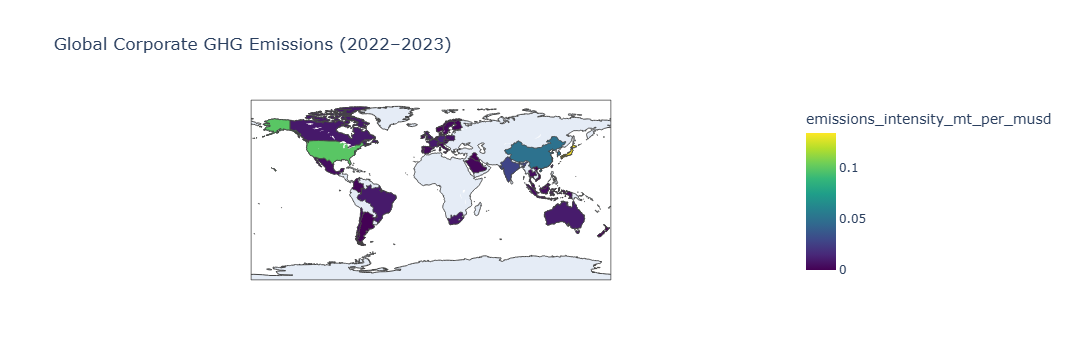

In [17]:
# Create the figure that will contain the map
fig = px.choropleth(
    country_emissions,
    locations="iso_code",
    color="emissions_intensity_mt_per_musd",
    hover_name="country",
    color_continuous_scale="Viridis", # Use a color map
    title="Global Corporate GHG Emissions (2022–2023)" # Add a title
)

fig.show()

## Export the Map as HTML

This allows us to host the interactive map on GitHub Pages.


In [18]:
fig.write_html("emissions_map.html")
print("Map exported as emissions_map.html")


Map exported as emissions_map.html


## Next Steps

- Upload `emissions_map.html` to your GitHub repository  
- Add a screenshot of the map to `images/map_preview.png`  
- Link everything in your `index.html` homepage  
